<a href="https://colab.research.google.com/github/bishalkshah70-art/AI-and-Ml-/blob/main/Support_vector_machine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [4]:
df = pd.read_csv("/content/breast_cancer_wisconsin_svm1_9c0cf15e-636f-4b5d-b330-243d31871487_268917_.csv")

In [9]:
x =df.drop(columns=["target", "diagnosis"])
y=df["target"]


In [10]:
print(f"Dataset shape: {df.shape}")
print(f"Number of Features: {x.shape[1]}")

Dataset shape: (569, 32)
Number of Features: 30


In [12]:
print("\nSpliting data into Train and Test sets...")


x_train,x_test,y_train,y_test = train_test_split(
    x,
    y,
    test_size = 0.20,
    random_state = 42
)

print("Training samples:",len(x_train))
print("Testing samples:",len(x_test))


Spliting data into Train and Test sets...
Training samples: 455
Testing samples: 114


In [14]:
print("\nApplying StandardScaler...")

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


Applying StandardScaler...


In [17]:
print("\nTraning Linear SVM...")
linear_svm = SVC(C=0.1, random_state=42)


Traning Linear SVM...


In [18]:
linear_svm.fit(x_train_scaled,y_train)

SVC(C=0.1, random_state=42)

In [23]:
print("Training RBF Kernal SVM...")

rbf_svm = SVC(
kernel="rbf",
C=1.0,
probability=True,
random_state=42
)

rbf_svm.fit(x_train_scaled,y_train)

Training RBF Kernal SVM...


SVC(probability=True, random_state=42)

In [24]:
print("\n" + "=" * 60)
print("MODEL EVALUATION")
print("=" * 60)


MODEL EVALUATION


In [25]:
y_pred_linear = linear_svm.predict(x_test_scaled)
print("\nLinear SVM RESULTS")
print("-" * 60)
print(f"Accuracy: {accuracy_score(y_test,y_pred_linear)}")
print("-" * 60)


Linear SVM RESULTS
------------------------------------------------------------
Accuracy: 0.9473684210526315
------------------------------------------------------------


In [26]:
print(
    classification_report(
    y_test,
    y_pred_linear,
    target_names=["Malignant", "Benign"]
))

              precision    recall  f1-score   support

   Malignant       0.95      0.91      0.93        43
      Benign       0.95      0.97      0.96        71

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



In [33]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt


Displaying Confusion Matrix...


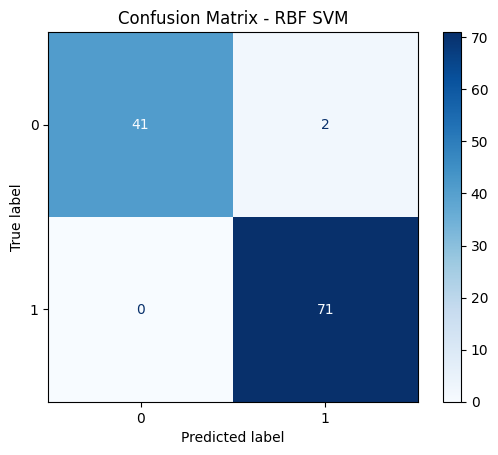

In [34]:
print("\nDisplaying Confusion Matrix...")

ConfusionMatrixDisplay.from_estimator(
    rbf_svm,
    x_test_scaled,
    y_test,
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix - RBF SVM")
plt.show()

In [35]:
print("\n" + "="*60)
print("LIVE PREDICTION ON UNSEEN PATIENTS")
print("=" *60)


LIVE PREDICTION ON UNSEEN PATIENTS


In [36]:
patient_1 = [
20.5, 22.1, 135.0, 1300.0, 0.12,
0.18, 0.22, 0.12, 0.22, 0.07,
1.2, 1.1, 8.5, 150.0, 0.007,
0.03, 0.04, 0.02, 0.02, 0.004,
25.0, 30.0, 170.0, 1800.0, 0.16,
0.30, 0.35, 0.18, 0.35, 0.09
]


patient_2 = [
11.0, 13.0, 70.0, 350.0, 0.09,
0.05, 0.02, 0.01, 0.16, 0.05,
0.20, 0.50, 1.50, 20.0, 0.005,
0.01, 0.01, 0.005, 0.01, 0.002,
12.0, 15.0, 80.0, 450.0, 0.11,
0.08, 0.05, 0.02, 0.20, 0.06
]



unseen_patients = pd.DataFrame(
    [patient_1,patient_2],
    columns=x.columns
)

In [42]:
unseen_scaled = scaler.transform(unseen_patients)
predictions = rbf_svm.predict(
unseen_scaled
)
probabilities = rbf_svm.predict_proba(
unseen_scaled
)

In [45]:
print("\nPrediction Results\n")

for i in range(len(unseen_patients)):
    diagnosis = (
        "Malignant (Cancerous)"
        if predictions[i] == 0
        else "Benign (Non-Cancerous)"
    )

    print(f"Patient {i+1}: {diagnosis}")


Prediction Results

Patient 1: Malignant (Cancerous)
Patient 2: Benign (Non-Cancerous)
